## 1. IMPORTS

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import os

# ML libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Expermint: SBERT
from sentence_transformers import SentenceTransformer

# Saving
import joblib

# Plotting
import matplotlib.pyplot as plt

C:\Users\avand\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. LOAD DATASET

In [2]:
# Load 20 Newsgroups dataset

def load_dataset():
    data = fetch_20newsgroups(remove=("headers", "footers", "quotes"))

    df = pd.DataFrame({
        "article_id": range(len(data.data)),
        "content": data.data,
        "category": data.target
    })

    return df

df = load_dataset()
df.head()

,article_id,content,category
0,0,I was wondering if anyone out there could enli...,7
1,1,A fair number of brave souls who upgraded thei...,4
2,2,"well folks, my mac plus finally gave up the gh...",4
3,3,\nDo you have Weitek's address/phone number? ...,1
4,4,"From article <C5owCB.n3p@world.std.com>, by to...",14


## 3. DATASET OVERVIEW (EDA)

In [3]:
def dataset_overview(df):
    print("\nDATASET OVERVIEW")
    print("Total docs:", len(df))
    print("Missing:", df["content"].isna().sum())
    print("Empty:", (df["content"].str.strip() == "").sum())
    print("Duplicates:", df["content"].duplicated().sum())

dataset_overview(df)


DATASET OVERVIEW
Total docs: 11314
Missing: 0
Empty: 300
Duplicates: 320


## 4. PREVIEW DATA

In [4]:
def preview_data(df, n=3):
    print("\nDATA SAMPLE:")
    print(df.head(n))

    print("\nSAMPLE TEXT:")
    for i, text in enumerate(df["content"].head(n)):
        print(f"\n--- Document {i} ---")
        print(text[:200])

preview_data(df)


DATA SAMPLE:
   article_id                                            content  category
0           0  I was wondering if anyone out there could enli...         7
1           1  A fair number of brave souls who upgraded thei...         4
2           2  well folks, my mac plus finally gave up the gh...         4

SAMPLE TEXT:

--- Document 0 ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were 

--- Document 1 ---
A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed at

--- Document 2 ---
well folks, my mac plus finally gave up the ghost this weekend after
starting life as a 512k way back in 1985.  sooo, i'm in the market for a
new machine a bit sooner than i intended to be...

i'm loo


## 5. DATA CLEANING (IMPORTANT)

In [5]:
# Remove bad data

df = df.dropna(subset=["content"])
df = df[df["content"].str.strip() != ""]
df = df.drop_duplicates(subset=["content"])

print("After cleaning:", len(df))

After cleaning: 10981


## 6. LENGTH ANALYSIS

In [6]:
def length_analysis(df):
    df["word_count"] = df["content"].fillna("").apply(lambda x: len(x.split()))
    print(df["word_count"].describe())
    return df

df = length_analysis(df)

count    10981.000000
mean       191.149531
std        530.898019
min          1.000000
25%         43.000000
50%         86.000000
75%        171.000000
max      11765.000000
Name: word_count, dtype: float64


## 7. PREPROCESSING

In [7]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["content"].apply(preprocess)

## 8. TF-IDF VECTORIZATION

In [8]:
def train_tfidf(corpus, max_features=10000):
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
    X = vectorizer.fit_transform(corpus)
    return vectorizer, X

corpus = df["clean_text"].tolist()
tfidf, X = train_tfidf(corpus)

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (10981, 10000)


## 8.5 SBERT

In [19]:
def train_sbert(corpus, model_name="all-MiniLM-L6-v2"):

    # If embeddings already exist → load them
    if os.path.exists("artifacts/sbert_vectors.npy"):
        print("Loading SBERT embeddings from file...")
        embeddings = np.load("artifacts/sbert_vectors.npy")
        model = SentenceTransformer(model_name)
        return model, embeddings

    model = SentenceTransformer(model_name)
    embeddings = model.encode(corpus, show_progress_bar=True)
    return model, embeddings

sbert_model, X_sbert = train_sbert(corpus)

print("SBERT Shape:", X_sbert.shape)

Loading SBERT embeddings from file...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2820.63it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT Shape: (10981, 384)


## 9. TF-IDF EDA

In [10]:
def tfidf_eda(vectorizer, X):
    print("\nTF-IDF INFO")
    print("Shape:", X.shape)

    sparsity = 1 - (X.nnz / (X.shape[0] * X.shape[1]))
    print("Sparsity:", round(sparsity, 4))

    feature_names = vectorizer.get_feature_names_out()
    scores = X.sum(axis=0).A1

    top_idx = scores.argsort()[::-1][:10]

    print("\nTop words:")
    for i in top_idx:
        print(feature_names[i])

tfidf_eda(tfidf, X)


TF-IDF INFO
Shape: (10981, 10000)
Sparsity: 0.9949

Top words:
like
just
know
don
people
does
think
use
thanks
good


## 10. PCA (DIMENSION REDUCTION)

In [11]:
def reduce_dimensions(X, n_components=100):  # parameter added
    X_dense = X.toarray()  # Note: may not scale for huge datasets

    pca = PCA(n_components=n_components, random_state=42)
    X_reduced = pca.fit_transform(X_dense)

    return pca, X_reduced

pca, X_reduced = reduce_dimensions(X)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (10981, 100)


## 11. K-MEANS CLUSTERING

In [12]:
def train_kmeans(X, n_clusters=20):  # CHANGE: configurable
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)
    return kmeans, clusters

# TF-IDF clusters
kmeans, clusters = train_kmeans(X_reduced)

# SBERT clusters
kmeans_sbert, clusters_sbert = train_kmeans(X_sbert)

## 12. CLUSTER EVALUATION

In [13]:
def evaluate_clusters(X, labels):
    score = silhouette_score(X, labels)
    print("Silhouette Score:", score)

print("\nTF-IDF + PCA Clustering:")
evaluate_clusters(X_reduced, clusters)

print("\nSBERT Clustering:")
evaluate_clusters(X_sbert, clusters_sbert)


TF-IDF + PCA Clustering:
Silhouette Score: 0.04674255104541796

SBERT Clustering:
Silhouette Score: 0.034097157418727875


## 13. SAVE / LOAD FUNCTIONS

In [14]:
def save_pickle(obj, path):
    joblib.dump(obj, path)

def load_pickle(path):
    return joblib.load(path)

def save_numpy(arr, path):
    np.save(path, arr)

def load_numpy(path):
    return np.load(path)

## 14. PIPELINES

In [15]:
def tfidf_pipeline(corpus):
    tfidf, X = train_tfidf(corpus)
    pca, X_reduced = reduce_dimensions(X)
    return tfidf, pca, X_reduced

def sbert_pipeline(corpus):
    model, X = train_sbert(corpus)
    return model, X

## 15. TRAIN FUNCTION (IMPORTANT)

In [16]:
def train():
    print("Loading dataset...")
    df = load_dataset()

    # Cleaning
    df = df.dropna(subset=["content"])
    df = df[df["content"].str.strip() != ""]
    df = df.drop_duplicates(subset=["content"])

    print("Preprocessing...")
    df["clean_text"] = df["content"].apply(preprocess)

    corpus = df["clean_text"].tolist()


    # TF-IDF PIPELINE

    print("Running TF-IDF pipeline...")
    tfidf, pca, X_reduced = tfidf_pipeline(corpus)

    print("Training KMeans (TF-IDF)...")
    kmeans, clusters = train_kmeans(X_reduced)


    # SBERT PIPELINE

    print("Running SBERT pipeline...")
    sbert_model, X_sbert = sbert_pipeline(corpus)

    print("Training KMeans (SBERT)...")
    kmeans_sbert, clusters_sbert = train_kmeans(X_sbert)


    # SAVE

    print("Saving artifacts...")

    os.makedirs("artifacts", exist_ok=True)

    save_pickle(tfidf, "artifacts/tfidf.pkl")
    save_pickle(pca, "artifacts/pca.pkl")
    save_pickle(kmeans, "artifacts/kmeans.pkl")

    # For Sbert
    save_pickle(sbert_model, "artifacts/sbert.pkl")
    save_pickle(kmeans_sbert, "artifacts/kmeans_sbert.pkl")

    save_numpy(X_reduced, "artifacts/vectors.npy")
    save_numpy(X_sbert, "artifacts/sbert_vectors.npy")

    print("Training complete!")

    return df, X_reduced, X_sbert, clusters, clusters_sbert

## 15. RUN TRAIN

In [17]:
df, tfidf_vectors, sbert_vectors, clusters, clusters_sbert = train()

Loading dataset...
Preprocessing...
Running TF-IDF pipeline...
Training KMeans (TF-IDF)...
Running SBERT pipeline...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6046.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 344/344 [06:14<00:00,  1.09s/it]


Training KMeans (SBERT)...
Saving artifacts...
Training complete!


# Visualization

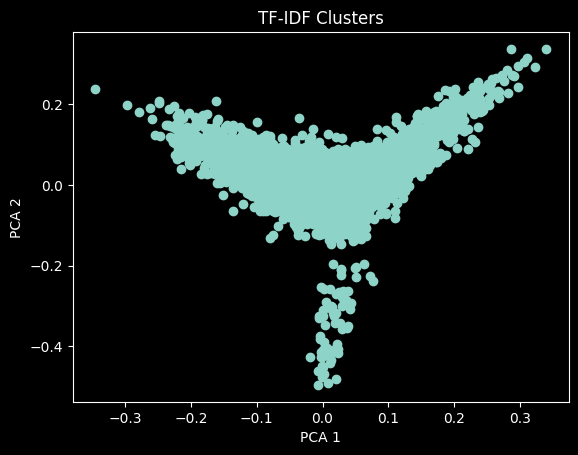

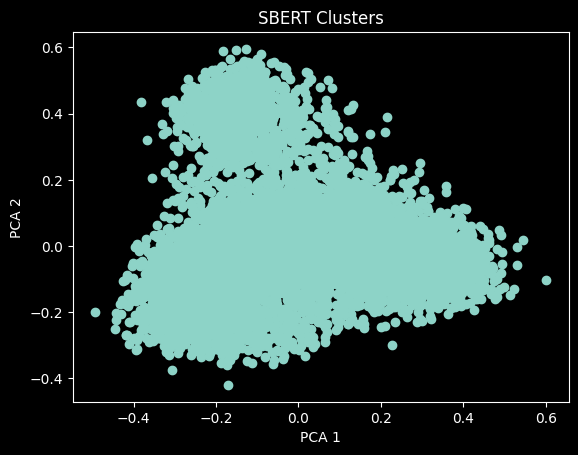

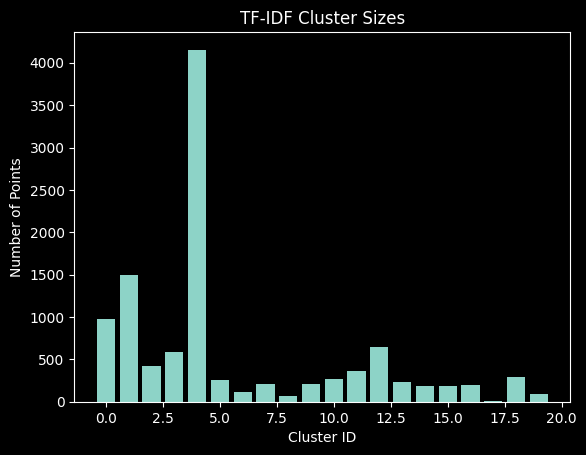

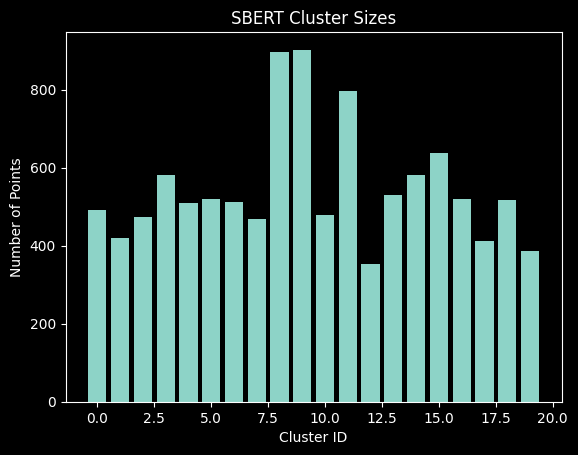

In [18]:
# Cluster Scatter Plot
def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure()
    plt.scatter(X_2d[:, 0], X_2d[:, 1])
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()


# TF-IDF
plot_clusters(tfidf_vectors, clusters, "TF-IDF Clusters")

# SBERT
plot_clusters(sbert_vectors, clusters_sbert, "SBERT Clusters")


# Cluster Size Distribution
def plot_cluster_sizes(labels, title):
    unique, counts = np.unique(labels, return_counts=True)

    plt.figure()
    plt.bar(unique, counts)
    plt.title(title)
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Points")
    plt.show()


# TF-IDF
plot_cluster_sizes(clusters, "TF-IDF Cluster Sizes")

# SBERT
plot_cluster_sizes(clusters_sbert, "SBERT Cluster Sizes")